**<span style="font-size:20px; color: LightBlue;">This file is created for Logistic Regression modeling</span>**

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
import warnings
warnings.filterwarnings("ignore")

In [31]:
df=pd.read_csv('creditcard.csv')

**<span style="font-size:20px; color: LightBlue;">Function to split features and target variable, preprocess data, and return train-test splits</span>**

In [32]:
# Function to slpit the data into train and test data
def splitFeatureTarget():

    X = df.drop('Class', axis=1)
    y = df['Class']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    return X_train, X_test, y_train, y_test

In [33]:

X_train, X_test, y_train, y_test = splitFeatureTarget()
print("\n Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\n Class distribution in train:\n", y_train.value_counts())
print("\n Class distribution in test:\n", y_test.value_counts())



 Train shape: (227845, 30) Test shape: (56962, 30)

 Class distribution in train:
 Class
0    227451
1       394
Name: count, dtype: int64

 Class distribution in test:
 Class
0    56864
1       98
Name: count, dtype: int64


**<span style="font-size:20px; color: LightBlue;">Function to evaluate model performance using various metrics</span>**

In [34]:
#Function created which performs the following tasks:
#1. Training model to output a prediction for each observation
#2. Evaluating the model performance using accuracy, confusion matrix, and classification report
#3. Printing the model performance metrics
#4. Plotting the confusion matrix

def evaluateModelPerf(model, X_test, y_test):
    # Performing step #1
    y_pred = model.predict(X_test)

    # Performing step #2
    accuracy = accuracy_score(y_test, y_pred)
    #matrix = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, digits=4)

    # Performing step #3
    print("\n Accuracy:", accuracy)
    print("\n Classification Report:\n", report)
    print("\n Confusion Matrix:")

    # Performing step #4
    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    disp.figure_.set_size_inches(4, 4)
    plt.show()

**<span style="font-size:20px; color: LightBlue;">Function to create ROC AUC curve for the model</span>**

In [41]:
#Function created which performs the following tasks:
#1. Predicting probabilities of class 1 on model
#2. Calculating ROC curve and AUC using inbuilt functions
#3. Plotting and displaying ROC AUC curve
#4. Creating legend and grid for the plot for better visualization

def createRocAucCurve(model,X_test,y_test,title):
    
    # Performing step #1
    #y_probability = model.predict_proba(X_test)[:, 1]  
    y_prob = model.decision_function(X_test)

    #Saving the variable for final model comparisons
    np.save("results/logistic_y_prob.npy", y_prob)
    np.save("results/y_true.npy", y_test)

    # Performing step #2
    roc_auc = roc_auc_score(y_test, y_prob)
    print(f"ROC-AUC: {roc_auc:.4f}")
    
    precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall, precision)
    print(f"PR AUC: {pr_auc:.4f}")
    
    # Ploting Precision-Recall curve
    plt.figure(figsize=(6,5))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    #plt.title(f"Precision-Recall Curve (Logistic Regression Model) ")
    plt.title(f"Precision-Recall Curve ({title})")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

**<span style="font-size:30px; color: LightBlue;">Implementation of Logistic Regression without regularization</span>**

In [42]:
# Implementing Logistic Regression Model without regularization

# Calling the function to split the dataset into features and target variable
X_train, X_test, y_train, y_test = splitFeatureTarget()

#Build & Train logistic regression model without regularization (using penalty=None)
lrModel = Pipeline(steps=[
    ('clf', LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000,class_weight='balanced'))
])

# Fitting the logistic regression model on the training data
lrModel.fit(X_train, y_train)

,steps,"[('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'


Logistic Regression Model without Regularization Performance Metrics:


 Accuracy: 0.974474210877427

 Classification Report:
               precision    recall  f1-score   support

           0     0.9999    0.9746    0.9871     56864
           1     0.0586    0.9184    0.1102        98

    accuracy                         0.9745     56962
   macro avg     0.5292    0.9465    0.5486     56962
weighted avg     0.9982    0.9745    0.9855     56962


 Confusion Matrix:


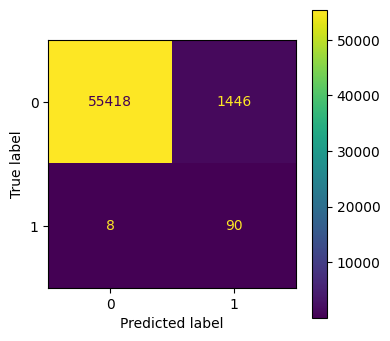

ROC-AUC: 0.9717
PR AUC: 0.7440


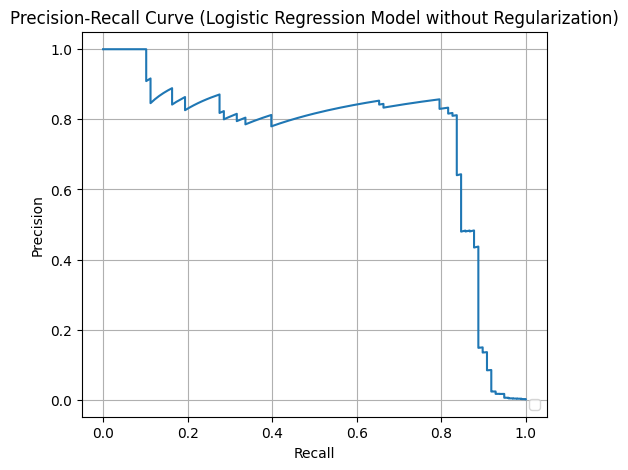

In [43]:
# Calling the function to evaluate the model performance of the logistic regression model without regularization
print("Logistic Regression Model without Regularization Performance Metrics:\n")
evaluateModelPerf(lrModel, X_test, y_test)


# Calling the function to create ROC AUC curve for the model with L1 regularization
createRocAucCurve(lrModel, X_test, y_test,"Logistic Regression Model without Regularization")

**<span style="font-size:30px; color: LightBlue;">Implementation of Logistic Regression with L1 regularization</span>**

In [13]:
# Implementing Logistic Regression Model with L1 regularization with class weight

# Calling the function to split the dataset into features and target variable
X_train, X_test, y_train, y_test = splitFeatureTarget()

# Logistic Regression with L1 regularization (Lasso; penalty='l1')
lrModel_l1_bal = LogisticRegression(penalty='l1', solver='saga', max_iter=1000, class_weight='balanced')
pipe_l1 = Pipeline(steps=[
    ('clf', lrModel_l1_bal) 
])

# Fitting the logistic regression model with L1 regularization on the training data
pipe_l1.fit(X_train, y_train)

,steps,"[('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'


Logistic Regression Model with L1 Regularization Performance Metrics:


 Accuracy: 0.9979986657771848

 Classification Report:
               precision    recall  f1-score   support

           0     0.9983    0.9997    0.9990     56864
           1     0.1000    0.0204    0.0339        98

    accuracy                         0.9980     56962
   macro avg     0.5492    0.5100    0.5164     56962
weighted avg     0.9968    0.9980    0.9973     56962


 Confusion Matrix:


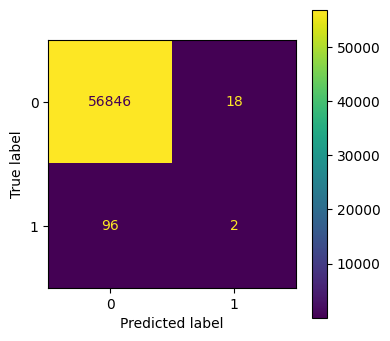

ROC-AUC: 0.6359
PR AUC: 0.0068


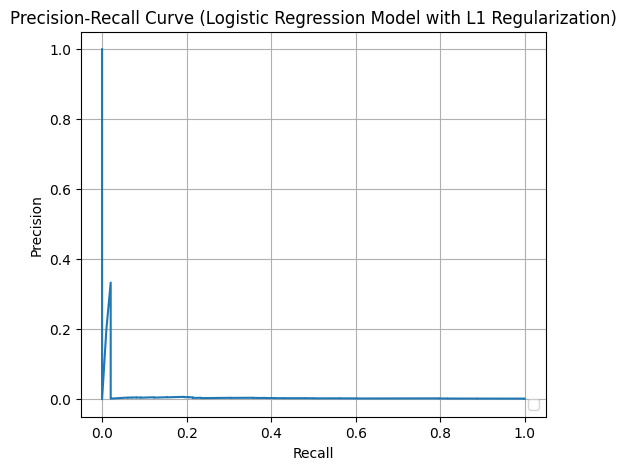

In [25]:
print("Logistic Regression Model with L1 Regularization Performance Metrics:\n")
# Calling the function to evaluate the model performance of the logistic regression model with L1 regularization
evaluateModelPerf(pipe_l1, X_test, y_test)

# Calling the function to create ROC AUC curve for the model with L1 regularization
createRocAucCurve(pipe_l1, X_test, y_test,"Logistic Regression Model with L1 Regularization")

**<span style="font-size:30px; color: LightBlue;">Implementation of Logistic Regression with L2 regularization</span>**

In [18]:
# Implementing Logistic Regression Model with L2 regularization with class weight

# Calling the function to split the dataset into features and target variable
X_train, X_test, y_train, y_test = splitFeatureTarget()

# Logistic Regression with L2 regularization (Ridge ; penalty='l2')
lrModel_l2_bal = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, class_weight='balanced')
pipe_l2 = Pipeline(steps=[
    ('clf', lrModel_l2_bal)
])

# Fitting the logistic regression model with L2 regularization on the training data
pipe_l2.fit(X_train, y_train)


,steps,"[('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'


Logistic Regression Model with L2 Regularization Performance Metrics:


 Accuracy: 0.9742108774270566

 Classification Report:
               precision    recall  f1-score   support

           0     0.9999    0.9743    0.9869     56864
           1     0.0580    0.9184    0.1092        98

    accuracy                         0.9742     56962
   macro avg     0.5289    0.9463    0.5480     56962
weighted avg     0.9982    0.9742    0.9854     56962


 Confusion Matrix:


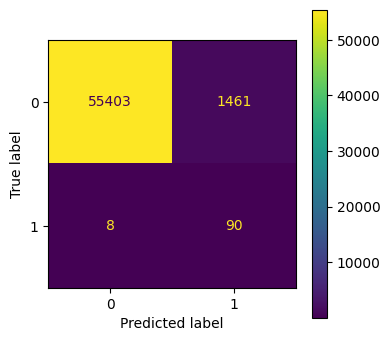

ROC-AUC: 0.9723
PR AUC: 0.7460


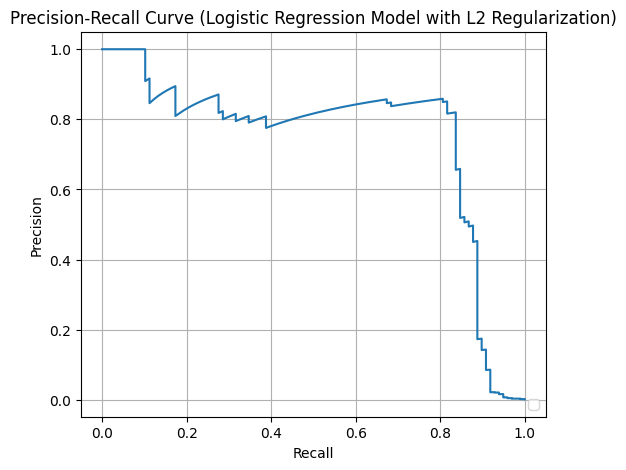

In [26]:
print("Logistic Regression Model with L2 Regularization Performance Metrics:\n")
# Calling the function to evaluate the model performance of the logistic regression model with L2 regularization
evaluateModelPerf(pipe_l2, X_test, y_test)

# Calling the function to create ROC AUC curve for the model with L2 regularization
createRocAucCurve(pipe_l2, X_test, y_test,"Logistic Regression Model with L2 Regularization")